### Sentiment Analysis

#### EDA
in that step import two dataset check abouit there features like whcih type of features exists in dataset1 nad dataset2

Import required libraries

In [1]:
# Data handling
import os
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

# Text processing
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

Step 2: Load the Dataset1

In [2]:
df1 = pd.read_csv("C:\\Users\\92324\\Desktop\\assesment\\sentiment_analysis_end_to_end\\src\\data\\sentimentdataset1.csv")
df1.tail()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
727,728,732,Collaborating on a science project that receiv...,Happy,2017-08-18 18:20:00,ScienceProjectSuccessHighSchool,Facebook,#ScienceFairWinner #HighSchoolScience,20.0,39.0,UK,2017,8,18,18
728,729,733,Attending a surprise birthday party organized ...,Happy,2018-06-22 14:15:00,BirthdayPartyJoyHighSchool,Instagram,#SurpriseCelebration #HighSchoolFriendship,25.0,48.0,USA,2018,6,22,14
729,730,734,Successfully fundraising for a school charity ...,Happy,2019-04-05 17:30:00,CharityFundraisingTriumphHighSchool,Twitter,#CommunityGiving #HighSchoolPhilanthropy,22.0,42.0,Canada,2019,4,5,17
730,731,735,"Participating in a multicultural festival, cel...",Happy,2020-02-29 20:45:00,MulticulturalFestivalJoyHighSchool,Facebook,#CulturalCelebration #HighSchoolUnity,21.0,43.0,UK,2020,2,29,20
731,732,736,Organizing a virtual talent show during challe...,Happy,2020-11-15 15:15:00,VirtualTalentShowSuccessHighSchool,Instagram,#VirtualEntertainment #HighSchoolPositivity,24.0,47.0,USA,2020,11,15,15


Get data information from dataset1

In [3]:
# Dataset info
print("\n📘 Dataset Information:")
df1.info()


📘 Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    str    
 3   Sentiment     732 non-null    str    
 4   Timestamp     732 non-null    str    
 5   User          732 non-null    str    
 6   Platform      732 non-null    str    
 7   Hashtags      732 non-null    str    
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    str    
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), str(7)
memory usage: 85.9 KB


In [4]:
df1.shape

(732, 15)

In [5]:
# randomly select 300 rows
df1_300 = df1.sample(n=300, random_state=42)

# save new dataset
df1_300.to_csv("df1_300.csv", index=False)

In [6]:
df1_300.shape
df1_300.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
604,605,609,Exploring the world of digital art. It's never...,Curiosity,2023-06-13 14:45:00,ArtAdventurer,Facebook,#ArtDiscovery #SeniorArtist,22.0,45.0,Canada,2023,6,13,14
33,34,35,Feeling inspired after attending a workshop. ...,Positive,2023-01-26 09:45:00,WorkshopAttendee,Instagram,#Inspiration #Workshop,25.0,50.0,USA,2023,1,26,9
300,301,305,"Eyes wide open in the night, fearful shadows ...",Fearful,2022-05-12 02:00:00,NightPrisoner,Facebook,#Fearful #ImaginedHorrors,18.0,36.0,India,2022,5,12,2
457,458,462,"A soul weathered by the storm of heartbreak, s...",Heartbreak,2019-04-18 11:00:00,StormSeeker,Twitter,#Heartbreak #CalmAfterStorm,22.0,45.0,Brazil,2019,4,18,11
634,635,639,"Attended a wine tasting event, savoring the ri...",Joy,2023-07-13 20:00:00,SeniorWineConnoisseur,Instagram,#AgedToPerfection #SeniorCheers,35.0,70.0,UK,2023,7,13,20


## now load data set and check its features

In [7]:
df2 = pd.read_csv("C:\\Users\\92324\Desktop\\assesment\\sentiment_analysis_end_to_end\\src\\data\\IMDB Dataset.csv")

In [8]:
df2.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [9]:
df2.shape

(50000, 2)

In [10]:
# randomly select 500 rows
df2_500 = df2.sample(n=500, random_state=42)

# save new dataset
df2_500.to_csv("df2_500.csv", index=False)

In [11]:
df2_500.shape

(500, 2)

In [12]:
df2_500.head()

,review,sentiment
33553,I really liked this Summerslam due to the look...,positive
9427,Not many television shows appeal to quite as m...,positive
199,The film quickly gets to a major chase scene w...,negative
12447,Jane Austen would definitely approve of this o...,positive
39489,Expectations were somewhat high for me when I ...,negative


### Consideration before merging

Here we can clearly see that there is miss match of feature in dataset1 and dataset2 like in dataset1 multiple extra features only required at momemt only text and sentiment features only so that thare will be no any type of miss mtching during mergig

In [13]:
df1_300 = df1_300[['Text', 'Sentiment']]

In [14]:
df1_300 = df1_300.rename(columns={'Text': 'review', 'Sentiment': 'sentiment'})
df1_300.head()

,review,sentiment
604,Exploring the world of digital art. It's never...,Curiosity
33,Feeling inspired after attending a workshop. ...,Positive
300,"Eyes wide open in the night, fearful shadows ...",Fearful
457,"A soul weathered by the storm of heartbreak, s...",Heartbreak
634,"Attended a wine tasting event, savoring the ri...",Joy


Now all unrequired features removed. now features are same as we required 

In [15]:
df_merged = pd.concat([df1_300, df2_500], axis=0).reset_index(drop=True)

In [17]:
df_merged.to_csv("df_merged.csv", index=False)

In [18]:
df_merged.head()

,review,sentiment
0,Exploring the world of digital art. It's never...,Curiosity
1,Feeling inspired after attending a workshop. ...,Positive
2,"Eyes wide open in the night, fearful shadows ...",Fearful
3,"A soul weathered by the storm of heartbreak, s...",Heartbreak
4,"Attended a wine tasting event, savoring the ri...",Joy


In [19]:
df_merged.shape

(800, 2)

Now explore our final dataset

In [20]:
# Dataset info
print("\n📘 Dataset Information:")
df_merged.info()


📘 Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     800 non-null    str  
 1   sentiment  800 non-null    str  
dtypes: str(2)
memory usage: 12.6 KB


In [22]:
# Check missing values
print("\n🔍 Missing Values:")
print(df_merged.isnull().sum())


🔍 Missing Values:
review       0
sentiment    0
dtype: int64


In [26]:
# Check unique sentiment labels
print("\n🎯 Sentiment Classes:")
print(df_merged['sentiment'].value_counts())


🎯 Sentiment Classes:
sentiment
negative          253
positive          247
 Positive          20
 Joy               19
 Excitement        10
                 ... 
 Empathetic         1
 Intimidation       1
 Dismissive         1
 Shame              1
 Pensive            1
Name: count, Length: 169, dtype: int64


In [27]:
positive_labels = ['positive', 'joy', 'excitement', 'happy', 'love', 'empathetic']
negative_labels = ['negative', 'anger', 'sad', 'fear', 'intimidation', 'shame', 'dismissive']

def map_sentiment(x):
    if x in positive_labels:
        return 'positive'
    elif x in negative_labels:
        return 'negative'
    else:
        return 'neutral'

df_merged['sentiment'] = df_merged['sentiment'].apply(map_sentiment)

In [29]:
# Check unique sentiment labels
print("\n🎯 Sentiment Classes:")
print(df_merged['sentiment'].value_counts())


🎯 Sentiment Classes:
sentiment
neutral     300
negative    253
positive    247
Name: count, dtype: int64


In [35]:
# save cleaned dataset
df_merged.to_csv("df_merged.csv", index=False)

In [39]:
df_merged.head()

,review,sentiment,Clean_sentiment
0,Exploring the world of digital art. It's never...,neutral,neutral
1,Feeling inspired after attending a workshop. ...,neutral,neutral
2,"Eyes wide open in the night, fearful shadows ...",neutral,neutral
3,"A soul weathered by the storm of heartbreak, s...",neutral,neutral
4,"Attended a wine tasting event, savoring the ri...",neutral,neutral


lets start text preprocessing

In [41]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)        # remove URLs
    text = re.sub(r"@\w+", "", text)           # remove mentions
    text = re.sub(r"#\w+", "", text)           # remove hashtags
    text = re.sub(r"[^a-z\s]", "", text)       # keep only letters
    text = " ".join([word for word in text.split() if word not in stop_words])
    return text.strip()

df_merged['Clean_review'] = df_merged['review'].apply(clean_text)
df_merged[['review', 'Clean_review']].head(10)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\92324\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,review,Clean_review
0,Exploring the world of digital art. It's never...,exploring world digital art never late discove...
1,Feeling inspired after attending a workshop. ...,feeling inspired attending workshop
2,"Eyes wide open in the night, fearful shadows ...",eyes wide open night fearful shadows dancing w...
3,"A soul weathered by the storm of heartbreak, s...",soul weathered storm heartbreak seeking refuge...
4,"Attended a wine tasting event, savoring the ri...",attended wine tasting event savoring richness ...
5,"Despite meticulous training, the swimmer faces...",despite meticulous training swimmer faces disa...
6,Excited about the upcoming gaming tournament....,excited upcoming gaming tournament
7,Reflecting on personal growth achieved through...,reflecting personal growth achieved life exper...
8,Achieving a personal best in a track and field...,achieving personal best track field competitio...
9,Immersed in the pulsating beats of a Bruno Mar...,immersed pulsating beats bruno mars concert up...


text analysis

C:\Users\92324\AppData\Local\Temp\ipykernel_15844\2236956782.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top, x='sentiment', y='word_count', palette='viridis', order=top_sentiments)


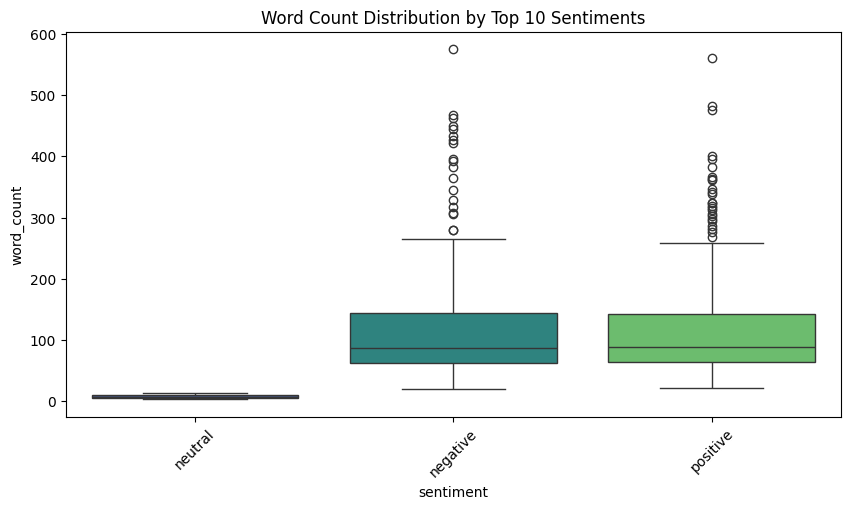


Top words for neutral:


,Word,Frequency
0,new,18
1,feeling,14
2,day,14
3,dreams,13
4,night,12



Top words for negative:


,Word,Frequency
0,br,608
1,movie,469
2,film,372
3,like,215
4,one,212



Top words for positive:


,Word,Frequency
0,br,540
1,film,415
2,movie,348
3,one,267
4,like,187


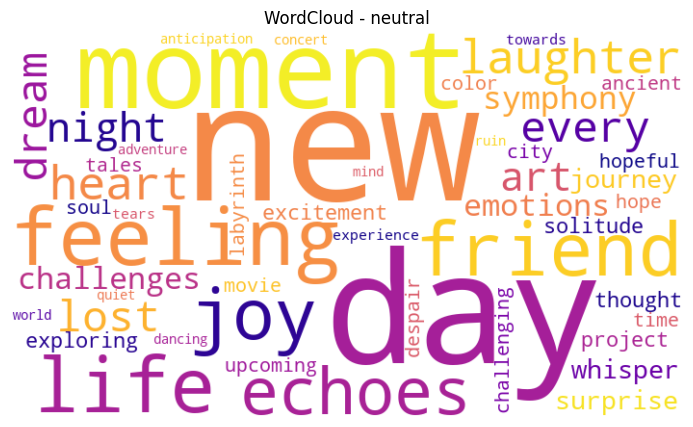

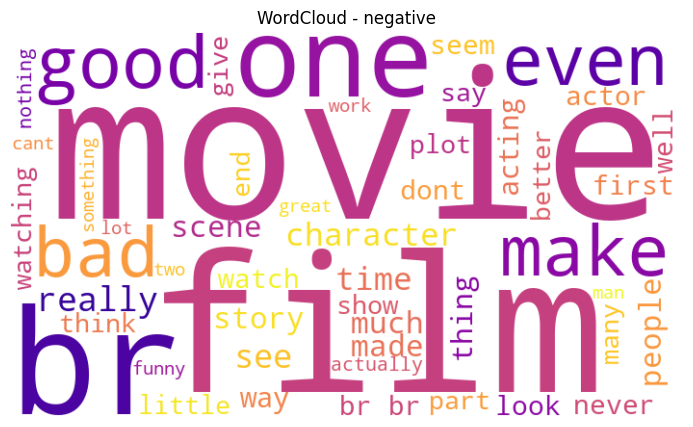

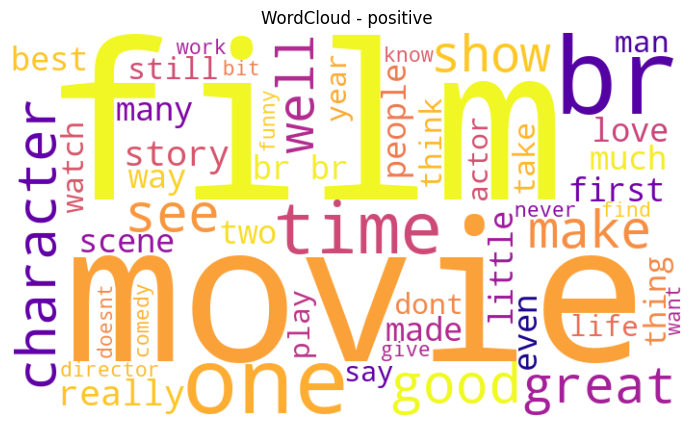

In [46]:
# Select top 10 most frequent sentiments
top_sentiments = df_merged['sentiment'].value_counts().nlargest(10).index
df_top = df_merged[df_merged['sentiment'].isin(top_sentiments)]

# 6.1 Average Word Count per Sentiment (Top 10)
df_top['word_count'] = df_top['Clean_review'].apply(lambda x: len(x.split()))
plt.figure(figsize=(10,5))
sns.boxplot(data=df_top, x='sentiment', y='word_count', palette='viridis', order=top_sentiments)
plt.title('Word Count Distribution by Top 10 Sentiments')
plt.xticks(rotation=45)
plt.show()

# 6.2 Most Common Words per Sentiment (Top 10 sentiments, top 5 words each)
def most_common_words(sentiment, n=5):
    words = " ".join(df_top[df_top['sentiment']==sentiment]['Clean_review']).split()
    common = Counter(words).most_common(n)
    return pd.DataFrame(common, columns=['Word','Frequency'])

for s in top_sentiments:
    print(f"\nTop words for {s}:")
    display(most_common_words(s, n=5))  # only top 5 words


# 6.3 WordClouds for Top 10 Sentiments
for sentiment in top_sentiments:
    text = " ".join(df_top[df_top['sentiment']==sentiment]['Clean_review'])
    wc = WordCloud(width=700, height=400, background_color='white', colormap='plasma', max_words=50).generate(text)
    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"WordCloud - {sentiment}")
    plt.show()

Feature Extraction

In [48]:
df_merged.to_csv("cleaned_sentiment_dataset.csv", index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
